# Chapter 7: Scientific Arrays with NumPy

Companion notebook for *Python by Curiosity*. Every code listing from the chapter is
here, in the order it appears in the book, under the same title. Run the cells from
top to bottom: some listings use variables or functions defined in earlier cells.

The same listings are also available as separate scripts in `codes/listings/ch07_arrays_numpy/`.

In [ ]:
# Run the listings from the repository root so that paths such as
# data/grades.csv and figures/trophy.png work.
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working folder:", os.getcwd())

### Code 7.1: Element-wise addition

In [2]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

print(a + b)    # [5 7 9]
print(a * b)    # [ 4 10 18]
print(a ** 2)   # [1 4 9]
print(a.dtype)  # int64 (int32 on some Windows set-ups)

[5 7 9]
[ 4 10 18]
[1 4 9]
int64


### Code 7.2: Array creation functions

In [3]:
import numpy as np

zeros_arr = np.zeros(5)           # [0. 0. 0. 0. 0.]
ones_mat = np.ones((2, 3))        # 2x3 matrix of 1.0
step_range = np.arange(0, 10, 2)  # [0 2 4 6 8]
lin_grid = np.linspace(0, 1, 5)   # [0.   0.25 0.5  0.75 1.  ]

### Code 7.3: 2-D arrays and slicing

In [4]:
import numpy as np

M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

print(M.shape)    # (3, 3)
print(M[1, 2])    # 6     (row 1, column 2)
print(M[:, 0])    # [1 4 7]  (all rows, column 0)
print(M[0, :])    # [1 2 3]  (row 0, all columns)

(3, 3)
6
[1 4 7]
[1 2 3]


### Code 7.4: Broadcasting

In [5]:
import numpy as np

a = np.array([10, 20, 30])
print(a + 5)    # [15 25 35]
print(a * 2)    # [20 40 60]

[15 25 35]
[20 40 60]


### Code 7.5: Matrix multiplication with @

In [6]:
import numpy as np

A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])
C = A @ B          # same as np.dot(A, B)
print(C)           # [[19 22]
                   #  [43 50]]

[[19 22]
 [43 50]]


### Code 7.6: Common ufuncs

In [7]:
import numpy as np

x = np.linspace(0, 2 * np.pi, 5)
print(np.sin(x).round(2))   # [ 0.  1.  0. -1. -0.]  (-0. is just a tiny negative rounded)
print(np.exp([0, 1, 2]))    # [1.         2.71828183 7.3890561 ]
print(np.sqrt([4, 9, 16]))  # [2. 3. 4.]

[ 0.  1.  0. -1. -0.]
[1.         2.71828183 7.3890561 ]
[2. 3. 4.]


### Code 7.7: Masks, reshape, and axis

In [8]:
import numpy as np

temps = np.array([21.5, 34.0, 28.2, 41.7, 19.9, 36.4])

hot = temps > 30              # a Boolean mask: True where the test holds
print(hot)
print(temps[hot])             # keep only the True positions
print(np.sum(hot))            # True counts as 1, so this counts them

capped = temps.copy()
capped[capped > 40] = 40.0    # change only the selected elements
print(capped)

grid = np.arange(6).reshape(2, 3)   # 6 numbers -> 2 rows, 3 columns
print(grid)
print(grid.sum(axis=0))       # down each column
print(grid.sum(axis=1))       # along each row
print(np.argmax(temps))       # index of the largest value

# Output:
# [False  True False  True False  True]
# [34.  41.7 36.4]
# 3
# [21.5 34.  28.2 40.  19.9 36.4]
# [[0 1 2]
#  [3 4 5]]
# [3 5 7]
# [ 3 12]
# 3

[False  True False  True False  True]
[34.  41.7 36.4]
3
[21.5 34.  28.2 40.  19.9 36.4]
[[0 1 2]
 [3 4 5]]
[3 5 7]
[ 3 12]
3


### Code 7.8: Saving and loading NumPy arrays with CSV

In [9]:
import numpy as np

# 1. Create a 2D array of sensor data (Time, Temp, Pressure)
data = np.array([
    [1.0, 23.4, 101.3],
    [2.0, 24.1, 101.5],
    [3.0, 23.8, 101.2]
])

# 2. Save array to a CSV file with a header row
np.savetxt("sensor_log.csv", data, delimiter=",", 
           fmt="%.2f", header="Time(s),Temp(C),Pressure(kPa)")

# 3. Load array back from the CSV file into Python
loaded_data = np.loadtxt("sensor_log.csv", delimiter=",", skiprows=1)
print("Loaded Array Shape:", loaded_data.shape)
print("Loaded Data:\n", loaded_data)

Loaded Array Shape: (3, 3)
Loaded Data:
 [[  1.   23.4 101.3]
 [  2.   24.1 101.5]
 [  3.   23.8 101.2]]


### Code 7.9: Numerical differentiation of y = sin(x)

In [10]:
import numpy as np

# 1. Create a fine grid for x and evaluate y = sin(x)
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

# 2. Compute numerical derivative dy/dx using array differences
dx = np.diff(x)
dy = np.diff(y)
slope_approx = dy / dx

# 3. Midpoint x-coordinates corresponding to differences
x_mid = (x[:-1] + x[1:]) / 2

# 4. Compare numerical slope with exact derivative cos(x)
exact_slope = np.cos(x_mid)
max_error = np.max(np.abs(slope_approx - exact_slope))
print(f"Maximum difference between dy/dx and cos(x): {max_error:.6f}")

Maximum difference between dy/dx and cos(x): 0.000168


### Try It Yourself: Bicycle Ramp Elevation & Steepness Calculator

In [11]:
import numpy as np

x = np.array([0, 1, 2, 3, 4, 5])
h = np.array([0.0, 0.2, 0.6, 1.2, 1.5, 1.6])

# Numerical slope = dh / dx
slope = np.diff(h) / np.diff(x)
print("Section Slopes (Rise / Run):", slope)
print(f"Steepest Section: {np.max(slope)*100:.1f}% grade")

Section Slopes (Rise / Run): [0.2 0.4 0.6 0.3 0.1]
Steepest Section: 60.0% grade


### Worked Example 7.1: Physics Kinematics & Trajectory Computation

[DEBUG] Grid created: 100 time points from 0.00s to 8.15s


[DEBUG] Derivative dy/dt computed for 99 interval midpoints
[DEBUG] Peak height reached at index 49, t = 4.04 s
Total Flight Time:       8.15 s
Numerical Max Height:    81.5411 m
Analytical Max Height:   81.5494 m
Discrepancy:             0.008321 m


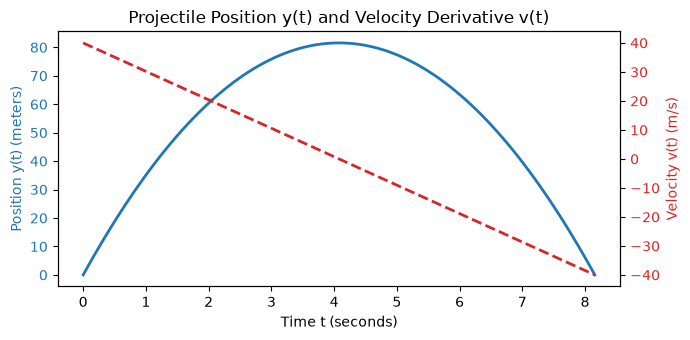

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants and initial conditions
v0 = 40.0      # initial velocity (m/s)
g = 9.81       # gravitational acceleration (m/s^2)
t_flight = 2 * v0 / g  # total time in air (~8.16 s)

# Step 1: Generate uniform time grid using np.linspace
t = np.linspace(0, t_flight, 100)
print(f"[DEBUG] Grid created: {len(t)} time points from {t[0]:.2f}s to {t[-1]:.2f}s")

# Step 2: Compute position and velocity vectorially
y = v0 * t - 0.5 * g * (t ** 2)
v = v0 - g * t

# Step 3: Compute numerical velocity dy/dt using array differences
dt = np.diff(t)
dy = np.diff(y)
v_num = dy / dt
t_mid = (t[:-1] + t[1:]) / 2
print(f"[DEBUG] Derivative dy/dt computed for {len(v_num)} interval midpoints")

# Step 4: Find maximum height numerically and analytically
h_max_num = np.max(y)
idx_max = np.argmax(y)
h_max_analytical = (v0 ** 2) / (2 * g)
print(f"[DEBUG] Peak height reached at index {idx_max}, t = {t[idx_max]:.2f} s")

print(f"Total Flight Time:       {t_flight:.2f} s")
print(f"Numerical Max Height:    {h_max_num:.4f} m")
print(f"Analytical Max Height:   {h_max_analytical:.4f} m")
print(f"Discrepancy:             {abs(h_max_num - h_max_analytical):.6f} m")

# Step 5: Plot position and velocity curves
fig, ax1 = plt.subplots(figsize=(7, 3.5))
color = 'tab:blue'
ax1.set_xlabel('Time t (seconds)')
ax1.set_ylabel('Position y(t) (meters)', color=color)
ax1.plot(t, y, color=color, linewidth=2, label='Position y(t)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Velocity v(t) (m/s)', color=color)
ax2.plot(t, v, color=color, linewidth=2, linestyle='--', label='Velocity v(t)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Projectile Position y(t) and Velocity Derivative v(t)')
fig.tight_layout()
plt.savefig('fig07-02-kinematics-derivative.pdf')

### Worked Example 7.2: Temperature Sensor Grid & Boolean Masking

In [13]:
import numpy as np

# 5x5 Temperature matrix (deg C) across plate
T = np.array([
    [25.0, 30.0, 32.0, 30.0, 25.0],
    [30.0, 42.5, 48.0, 43.0, 30.0],
    [32.0, 46.2, 51.5, 47.8, 32.0],
    [30.0, 41.0, 44.5, 40.0, 30.0],
    [25.0, 30.0, 32.0, 30.0, 25.0]
])
print(f"[DEBUG] Grid initialized: shape {T.shape}, total {T.size} sensors")

# Step 1: Extract interior 3x3 subgrid using 2D slicing
T_interior = T[1:4, 1:4]
print(f"[DEBUG] Extracted interior subgrid shape: {T_interior.shape}")

# Step 2: Boolean mask for critical temperatures
mask_overheat = T > 45.0
overheat_count = np.sum(mask_overheat)
print(f"[DEBUG] Found {overheat_count} sensors exceeding 45.0 C threshold")

# Step 3: Apply safety cap inplace
T_capped = T.copy()
T_capped[mask_overheat] = 45.0

print("Interior Subgrid (3x3):\n", T_interior)
print(f"Overheated Sensors Count: {overheat_count}")
print("Capped Matrix:\n", T_capped)

# Output:
# [DEBUG] Grid initialized: shape (5, 5), total 25 sensors
# [DEBUG] Extracted interior subgrid shape: (3, 3)
# [DEBUG] Found 4 sensors exceeding 45.0 C threshold
# Interior Subgrid (3x3):
#  [[42.5 48.  43. ]
#   [46.2 51.5 47.8]
#   [41.  44.5 40. ]]
# Overheated Sensors Count: 4
# Capped Matrix:
#  [[25.  30.  32.  30.  25. ]
#   [30.  42.5 45.  43.  30. ]
#   [32.  45.  45.  45.  32. ]
#   [30.  41.  44.5 40.  30. ]
#   [25.  30.  32.  30.  25. ]]

[DEBUG] Grid initialized: shape (5, 5), total 25 sensors
[DEBUG] Extracted interior subgrid shape: (3, 3)
[DEBUG] Found 4 sensors exceeding 45.0 C threshold
Interior Subgrid (3x3):
 [[42.5 48.  43. ]
 [46.2 51.5 47.8]
 [41.  44.5 40. ]]
Overheated Sensors Count: 4
Capped Matrix:
 [[25.  30.  32.  30.  25. ]
 [30.  42.5 45.  43.  30. ]
 [32.  45.  45.  45.  32. ]
 [30.  41.  44.5 40.  30. ]
 [25.  30.  32.  30.  25. ]]


### Worked Example 7.3: Linear Algebra - Electrical Circuit Mesh Solver

In [14]:
import numpy as np

# Resistance matrix A (Ohms) and Voltage vector v (Volts)
A = np.array([
    [12.0, -4.0,  0.0],
    [-4.0, 15.0, -5.0],
    [ 0.0, -5.0, 10.0]
])
v = np.array([24.0, 0.0, 0.0])
print(f"[DEBUG] Matrix A shape: {A.shape}, det(A): {np.linalg.det(A):.2f}")

# Step 1: Solve for currents i = A^(-1) * v
i = np.linalg.solve(A, v)
print(f"[DEBUG] Solved loop current vector i: {i}")

# Step 2: Compute residual error vector and 2-norm
residual = np.dot(A, i) - v
residual_norm = np.linalg.norm(residual)
print(f"[DEBUG] Computed residual norm ||A*i - v||: {residual_norm:.2e}")

print(f"Mesh Current i1: {i[0]:.4f} A")
print(f"Mesh Current i2: {i[1]:.4f} A")
print(f"Mesh Current i3: {i[2]:.4f} A")
print(f"Residual Norm:   {residual_norm:.2e}")

# Output:
# [DEBUG] Matrix A shape: (3, 3), det(A): 1340.00
# [DEBUG] Solved loop current vector i: [2.23880597 0.71641791 0.35820896]
# [DEBUG] Computed residual norm ||A*i - v||: 3.62e-15
# Mesh Current i1: 2.2388 A
# Mesh Current i2: 0.7164 A
# Mesh Current i3: 0.3582 A
# Residual Norm:   3.62e-15
# (The residual's last digits may differ slightly on your computer.)

[DEBUG] Matrix A shape: (3, 3), det(A): 1340.00
[DEBUG] Solved loop current vector i: [2.23880597 0.71641791 0.35820896]
[DEBUG] Computed residual norm ||A*i - v||: 3.62e-15
Mesh Current i1: 2.2388 A
Mesh Current i2: 0.7164 A
Mesh Current i3: 0.3582 A
Residual Norm:   3.62e-15


### Worked Example 7.4: Broadcasting - Pairwise 2D Distance Matrix

In [15]:
import numpy as np

# Coordinates of 4 stations (N, 2)
coords = np.array([
    [0.0, 0.0],   # Station A
    [3.0, 4.0],   # Station B
    [6.0, 8.0],   # Station C
    [10.0, 0.0]   # Station D
])

# Step 1: Expand dimensions for broadcasting (4, 1, 2) and (1, 4, 2)
P1 = coords[:, np.newaxis, :]  # Shape (4, 1, 2)
P2 = coords[np.newaxis, :, :]  # Shape (1, 4, 2)
print(f"[DEBUG] Reshaped station coordinates: P1 {P1.shape}, P2 {P2.shape}")

# Step 2: Compute coordinate differences and Euclidean distance
diff = P1 - P2                 # Shape (4, 4, 2)
D = np.sqrt(np.sum(diff ** 2, axis=-1))  # Shape (4, 4)
print(f"[DEBUG] Evaluated pairwise diff shape {diff.shape} -> distance D shape {D.shape}")

print("4x4 Pairwise Distance Matrix (km):\n", np.round(D, 2))

# Output:
# [DEBUG] Reshaped station coordinates: P1 (4, 1, 2), P2 (1, 4, 2)
# [DEBUG] Evaluated pairwise diff shape (4, 4, 2) -> distance D shape (4, 4)
# 4x4 Pairwise Distance Matrix (km):
#  [[ 0.    5.   10.   10.  ]
#   [ 5.    0.    5.    8.06]
#   [10.    5.    0.    8.94]
#   [10.    8.06  8.94  0.  ]]

[DEBUG] Reshaped station coordinates: P1 (4, 1, 2), P2 (1, 4, 2)
[DEBUG] Evaluated pairwise diff shape (4, 4, 2) -> distance D shape (4, 4)
4x4 Pairwise Distance Matrix (km):
 [[ 0.    5.   10.   10.  ]
 [ 5.    0.    5.    8.06]
 [10.    5.    0.    8.94]
 [10.    8.06  8.94  0.  ]]


### Worked Example 7.5: Astronomical Image Processing - Synthetic 7x7 CCD Telescope Grid

[DEBUG] Raw CCD grid: shape (7, 7), peak raw pixel = 255 ADU
[DEBUG] Filtered 1 cosmic-ray spike at index (array([2]), array([5]))
[DEBUG] Background suppressed: max peak = 147.5 ADU

--- Final Processed 7x7 Star Field Matrix (ADU) ---
[[  0.   27.5   0.    0.   26.    0.    0. ]
 [ 26.   57.5  68.   62.    0.    0.   27.5]
 [  0.   72.5 147.5  80.   27.5   0.    0. ]
 [  0.   65.  137.   68.   26.    0.    0. ]
 [  0.   27.5  62.   29.    0.    0.   26. ]
 [ 27.5   0.    0.    0.   50.   57.5   0. ]
 [  0.    0.   26.    0.   53.   47.    0. ]]


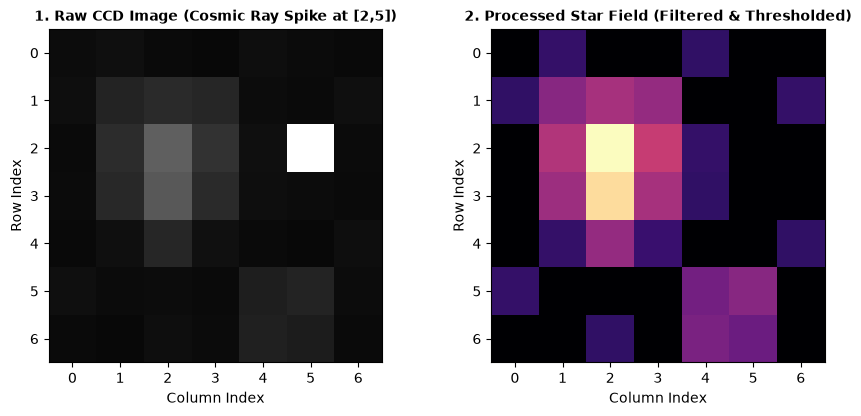

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Step 0: Raw 7x7 telescope CCD sensor grid (ADU counts)
raw_img = np.array([
    [ 12,  15,  10,   8,  14,  11,   9],
    [ 14,  35,  42,  38,  12,  10,  15],
    [ 10,  45,  95,  50,  15, 255,  11],  # 255 is a cosmic-ray noise spike!
    [ 11,  40,  88,  42,  14,  12,  10],
    [  9,  15,  38,  16,  10,   8,  14],
    [ 15,  11,  12,  10,  30,  35,  12],  # Faint star at bottom right
    [ 10,   8,  14,  11,  32,  28,  10]
], dtype=float)

print(f"[DEBUG] Raw CCD grid: shape {raw_img.shape}, peak raw pixel = {raw_img.max():.0f} ADU")

# Step 1: Cosmic ray filter using Boolean Masking (> 200 ADU -> 12.0 ADU)
cleaned = raw_img.copy()
mask_spike = cleaned > 200.0
cleaned[mask_spike] = 12.0
print(f"[DEBUG] Filtered {np.sum(mask_spike)} cosmic-ray spike at index {np.where(mask_spike)}")

# Step 2: Contrast & Brightness Enhancement (Vectorized scalar arithmetic)
enhanced = cleaned * 1.5 + 5.0

# Step 3: Background Sky Noise Suppression (Thresholding < 25.0 ADU -> 0.0 ADU)
processed = enhanced.copy()
processed[processed < 25.0] = 0.0
print(f"[DEBUG] Background suppressed: max peak = {processed.max():.1f} ADU")

print("\n--- Final Processed 7x7 Star Field Matrix (ADU) ---")
print(np.round(processed, 1))

# Step 4: Side-by-side plot of Raw vs Processed CCD grid
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.2))

ax1.imshow(raw_img, cmap='gray', vmin=0, vmax=255)
ax1.set_title("1. Raw CCD Image (Cosmic Ray Spike at [2,5])", fontsize=10, fontweight='bold')
ax1.set_xlabel("Column Index"); ax1.set_ylabel("Row Index")

ax2.imshow(processed, cmap='magma', vmin=0, vmax=processed.max())
ax2.set_title("2. Processed Star Field (Filtered & Thresholded)", fontsize=10, fontweight='bold')
ax2.set_xlabel("Column Index"); ax2.set_ylabel("Row Index")

plt.tight_layout()
plt.savefig("fig07-03-telescope-processing.pdf")

# Output:
# [DEBUG] Raw CCD grid: shape (7, 7), peak raw pixel = 255 ADU
# [DEBUG] Filtered 1 cosmic-ray spike at index (array([2]), array([5]))
# [DEBUG] Background suppressed: max peak = 147.5 ADU
# 
# --- Final Processed 7x7 Star Field Matrix (ADU) ---
# [[  0.  27.5   0.    0.   26.    0.    0. ]
#  [ 26.  57.5 68.  62.    0.    0.   27.5]
#  [  0.  72.5 147.5 80.   27.5   0.    0. ]
#  [  0.  65.  137.  68.   26.    0.    0. ]
#  [  0.  27.5 62.   29.    0.    0.   26. ]
#  [ 27.5  0.    0.    0.   50.   57.5   0. ]
#  [  0.    0.   26.    0.   53.   47.  0. ]]

### Real-World Solution

In [17]:
import numpy as np
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print(a + b)   # Output: [5 7 9]

[5 7 9]
